# Perturbation workshop

In [1]:
import glob, os, sys, json, jax, jax_obc2, jax_model, optax, scipy
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
import jax_amber2 as jaa
import jax.numpy as jnp
import numpy.random as npr
from flax import linen as nn 
from flax.training import train_state 
import mdtraj as md
#import MDAnalysis as mda
import matplotlib as mpl
import matplotlib.pyplot as plt
from decimal import Decimal

import VAE_AE_module3 as j
from sklearn.mixture import GaussianMixture

In [2]:
gas_fun, _, _, _ = j.get_amber_gas_energy_functions('Simulation/ala_deca_peptide.prmtop')

### Initializing the model & load from a checkpoint

In [3]:
# Experiment -> A
A = j.NN_Experiment('modelL_04_2.json')

FileNotFoundError: [Errno 2] No such file or directory: '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/'

In [5]:
A.load_model_from_ckpt('modelL/04_latents/rpt_2/model_ckpt_003481.pkl')

In [6]:
#print(A.state)    # I might not need to see shape here
A.epoch = 3481     # This seems important. I'll keep it

TrainState(step=Array(278480, dtype=int64, weak_type=True), apply_fn=<bound method Module.apply of VAE(
    # attributes
    input_size = 306
    hidden_layers = [306, 306, 306]
    dropout_rates = [0.3, 0.4, 0.5]
    latents = 4
)>, params={'encoder': {'Dense_0': {'kernel': Array([[ 2.22441759e-02,  7.60694146e-02, -8.46418291e-02, ...,
         7.35973241e-04,  1.09377159e-02, -1.01946495e-01],
       [ 1.54465735e-02,  1.12615399e-01, -8.44304338e-02, ...,
        -4.65016365e-02, -7.18799308e-02, -8.61687586e-02],
       [-5.90028316e-02, -5.65441065e-02, -6.12943731e-02, ...,
        -2.99171694e-02,  6.25871792e-02,  7.42461905e-02],
       ...,
       [ 7.36561120e-02, -7.20437020e-02, -1.91628151e-02, ...,
         3.53992321e-02, -6.89958483e-02, -6.67438433e-02],
       [ 4.37079137e-03,  6.11596927e-02, -3.36000696e-02, ...,
         6.57289129e-05, -4.69550723e-03,  1.22982403e-02],
       [-2.76818331e-02, -4.64190245e-02,  3.60818431e-02, ...,
         2.66281068e-02, -1.

### Auto Encode

In [ ]:
print(A.test_data.shape)
A.test_data

In [7]:
# Random Number Generator
rng_init = jax.random.PRNGKey(891)
rng, key = jax.random.split(rng_init)

# AutoEncode
recon = A.state.apply_fn({'params':A.state.params}, A.test_data, rng)

In [8]:
# Save DECODED test data
A.write_decoded_traj(idfn='test_decoded.dcd')

In [9]:
# Verify the shape of the output
recon[0].shape, recon[1].shape

((2000, 306), (2000, 4))

### Apply Gaussian Mixture & visualize data points.
not running it in perturbation

### Defining the coordinates

Hmmm so you auto encode even before you define the coordinates

In [13]:
# Defining the coordinates
c = md.load('Simulation/decaalanine_1us_split6.dcd', top='Simulation/ala_deca_peptide.prmtop')
c = c.superpose(c)    # Will this affect the coords variable?
coords = jnp.array(c.superpose(c).xyz)
print(coords.shape)   # Verify the shape of the coordinates

# Seems like I have to flatten the shape to do the perturbation
coords = coords.reshape(coords.shape[0], -1)
print(coords.shape)   # Re-Verify the shape of the coordinates

# rmsd = md.rmsd(c, c)

### Latents Perturbation

In [ ]:
# Select only 1 column of Array to perturb to identify data relation
# Initially, I tried minimal perturbation from 0.1 to 1 to each row in first column
# but decoded items are identical. Later I find that +31 is the least effective change.

perturbed_latents = jnp.array(recon[1]) # copy recon[1] to perturbed_latents
perturbed_latents = perturbed_latents.at[:, 0].add(1) # added perturbed_latents

print(perturbed_latents.shape) # confirm if the shape is still intact
perturbed_latents # print out pLatents

In [ ]:
### Printing original Decoded
# verify the shape and value of recon[0] cells

print(recon[0].shape)
recon[0]

### Decode perturbed latents

In [ ]:
### Perturbed Decoded
# decode the perturbed_latents and print out

decoded_samples = A.model.apply({'params': A.state.params}, perturbed_latents, rng, method=A.model.decode)

print(perturbed_decoded.shape)
perturbed_decoded

### Comparison

In [ ]:
### Comparison between original and perturbed Decoded
# if True means cells are same

def compare_arrays(arr1, arr2):

    diff_cells = jnp.argwhere(arr1 != arr2)
    
    return diff_cells

diff_cells = compare_arrays(recon[0], perturbed_decoded)
print(f"Different indices: {diff_cells}")

recon[0] == perturbed_decoded

In [22]:
# writing dcd for original test data
A.write_traj('ORIGINAL_LATENT', recon[0])
# writing dcd for GMM samples
A.write_traj('PERTURBED_LATENT', perturbed_decoded)

### Useful histogram comparison models

Excluding Outliers GMM - 51 RECON - 38


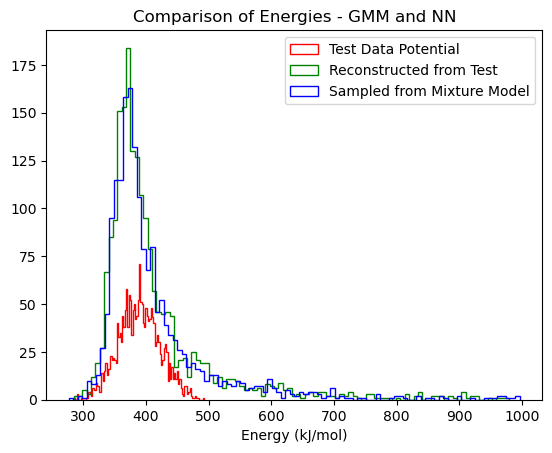

In [21]:
# # Energies comparison based on Guassian Mixture Model and the Neurral Networks
# plt.clf()
# X = np.array(recon[1])
# MM = GaussianMixture(n_components=11).fit(X) #chosen based on above graph
# samples = MM.sample(1800)[0]

# recon_energies = gas_fun(recon[0])

# # Samples are applied GMM
# # Yes! I can use this code to decode the perturbation
# decoded_samples = A.model.apply({'params': A.state.params}, samples, rng, method=A.model.decode)
# sampled_energies = gas_fun(decoded_samples)

# org_energies = gas_fun(A.test_data)

# threshold = 1e3
# num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
# num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
# print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

# _ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
# _ = plt.hist(recon_energies[recon_energies<threshold], bins=100, histtype='step', color='g')
# _ = plt.hist(sampled_energies[sampled_energies<threshold], bins=100, histtype='step', color='b')

# plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
# plt.xlabel('Energy (kJ/mol)')
# plt.title('Comparison of Energies - GMM and NN')
# plt.show()

In [ ]:
# #calculate average rmsd of each frame with repsect to other frames of traj
# test_self_rmsd = []
# c = md.load('modelL/04_latents/rpt_2/test_data_modelL04.dcd', top='Simulation/ala_deca_peptide.prmtop')
# d = md.load('modelL/04_latents/rpt_2/TEST_LATENT_modelL04.dcd', top='Simulation/ala_deca_peptide.prmtop')
# e = md.load('modelL/04_latents/rpt_2/GMM_SAMPLED_modelL04.dcd', top='Simulation/ala_deca_peptide.prmtop')

# rmsd_self_all = []
# for u in (c, d, e):
#     u = u.superpose(u)
#     print(u.xyz.shape)
#     rmsd_self = []
#     for i in range(u.xyz.shape[0]):
#         rmsd_self.append(md.rmsd(u,u,frame=i).mean())
#     rmsd_self_all.append(rmsd_self[:1800])

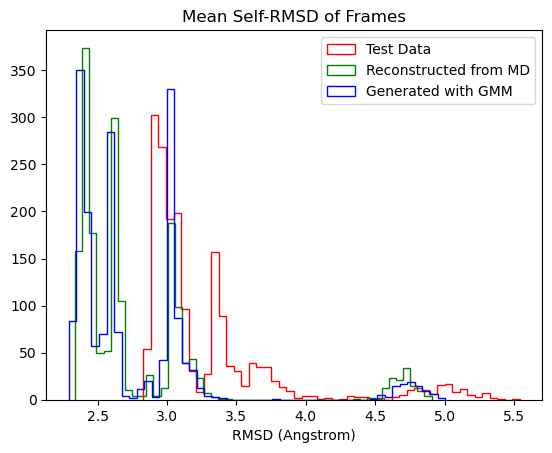

In [26]:
# colors = ['r', 'g', 'b']
# plt.clf()
# for i in range(3):
#     _ = plt.hist(rmsd[i,:]*10, bins=50, histtype='step', color=colors.pop(0))
# plt.legend(('Test Data', 'Reconstructed from MD', 'Generated with GMM'))
# plt.xlabel('RMSD (Angstrom)')
# plt.title('Mean Self-RMSD of Frames')
# plt.show()